# 01 — Data Exploration
**Loan Approval Prediction**

Goals:
- Load and inspect the dataset
- Understand column types and distributions
- Visualise class balance (Approved vs Rejected)
- Explore numerical and categorical feature distributions
- Correlation heatmap

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # make src/ importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import DATA_DIR, TARGET_COL, CATEGORICAL_COLS, NUMERICAL_COLS
from src.data_loader import load_dataset

print("Data directory:", DATA_DIR)

Data directory: /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_4_Loan_Approval_Prediction/data


## 1. Load Dataset

In [2]:
df = load_dataset()
display(df.head())
print(f"\nShape: {df.shape}")

Dataset  :  4269 rows  |  13 columns
Columns  : ['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



Shape: (4269, 13)


## 2. Dataset Overview

In [3]:
print("Column dtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

Column dtypes:
loan_id                     int64
no_of_dependents            int64
education                     str
self_employed                 str
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                   str
dtype: object

Missing values per column:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Total missing cells: 0


## 3. Target Class Distribution

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

Class ratio  (Approved/Rejected): 1.65


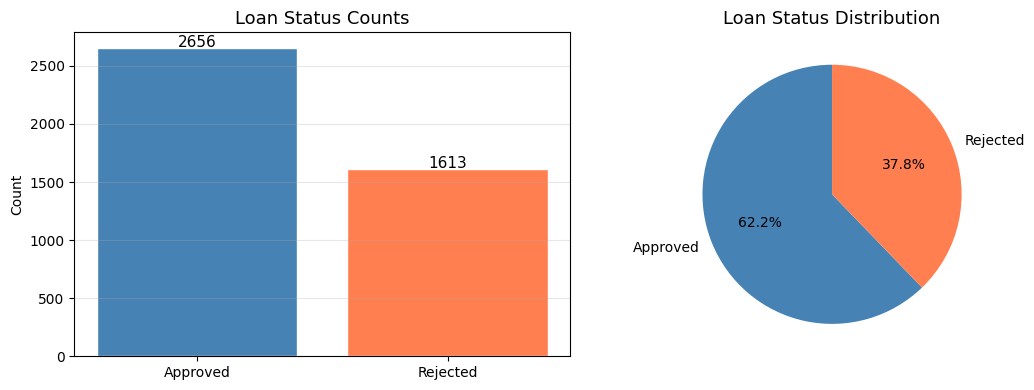

In [4]:
class_counts = df[TARGET_COL].value_counts()
print(class_counts)
print(f"\nClass ratio  (Approved/Rejected): {class_counts['Approved']/class_counts['Rejected']:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(class_counts.index, class_counts.values,
            color=['steelblue', 'coral'], edgecolor='white')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)
axes[0].set_title('Loan Status Counts', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'coral'], startangle=90)
axes[1].set_title('Loan Status Distribution', fontsize=13)

plt.tight_layout()
plt.show()

## 4. Numerical Feature Distributions

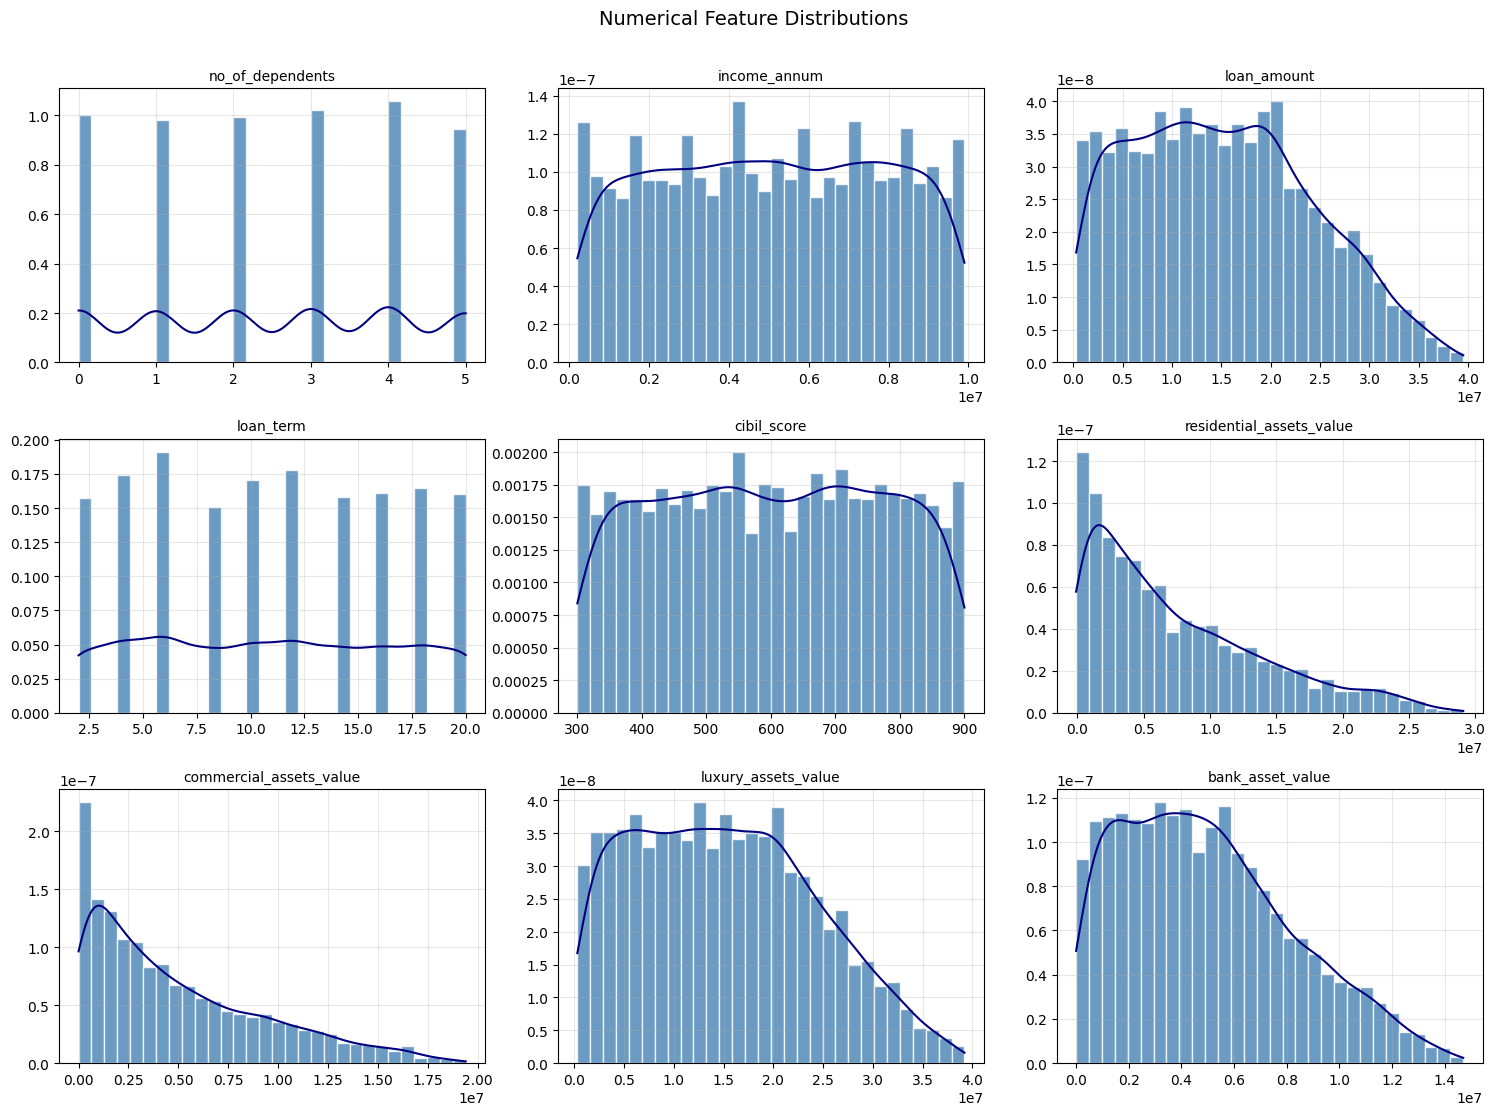

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()

for i, col in enumerate(NUMERICAL_COLS):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue',
                 edgecolor='white', alpha=0.8, density=True)
    # overlay KDE
    from scipy.stats import gaussian_kde
    data = df[col].dropna().values
    if data.std() > 0:
        kde = gaussian_kde(data)
        x_range = np.linspace(data.min(), data.max(), 200)
        axes[i].plot(x_range, kde(x_range), color='navy', linewidth=1.5)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].grid(alpha=0.3)

plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Numerical Features by Loan Status

/tmp/ipykernel_1637/1847293370.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1637/1847293370.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1637/1847293370.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1637/1847293370.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1637/1847293370.py:5: FutureWarning: 

Passin

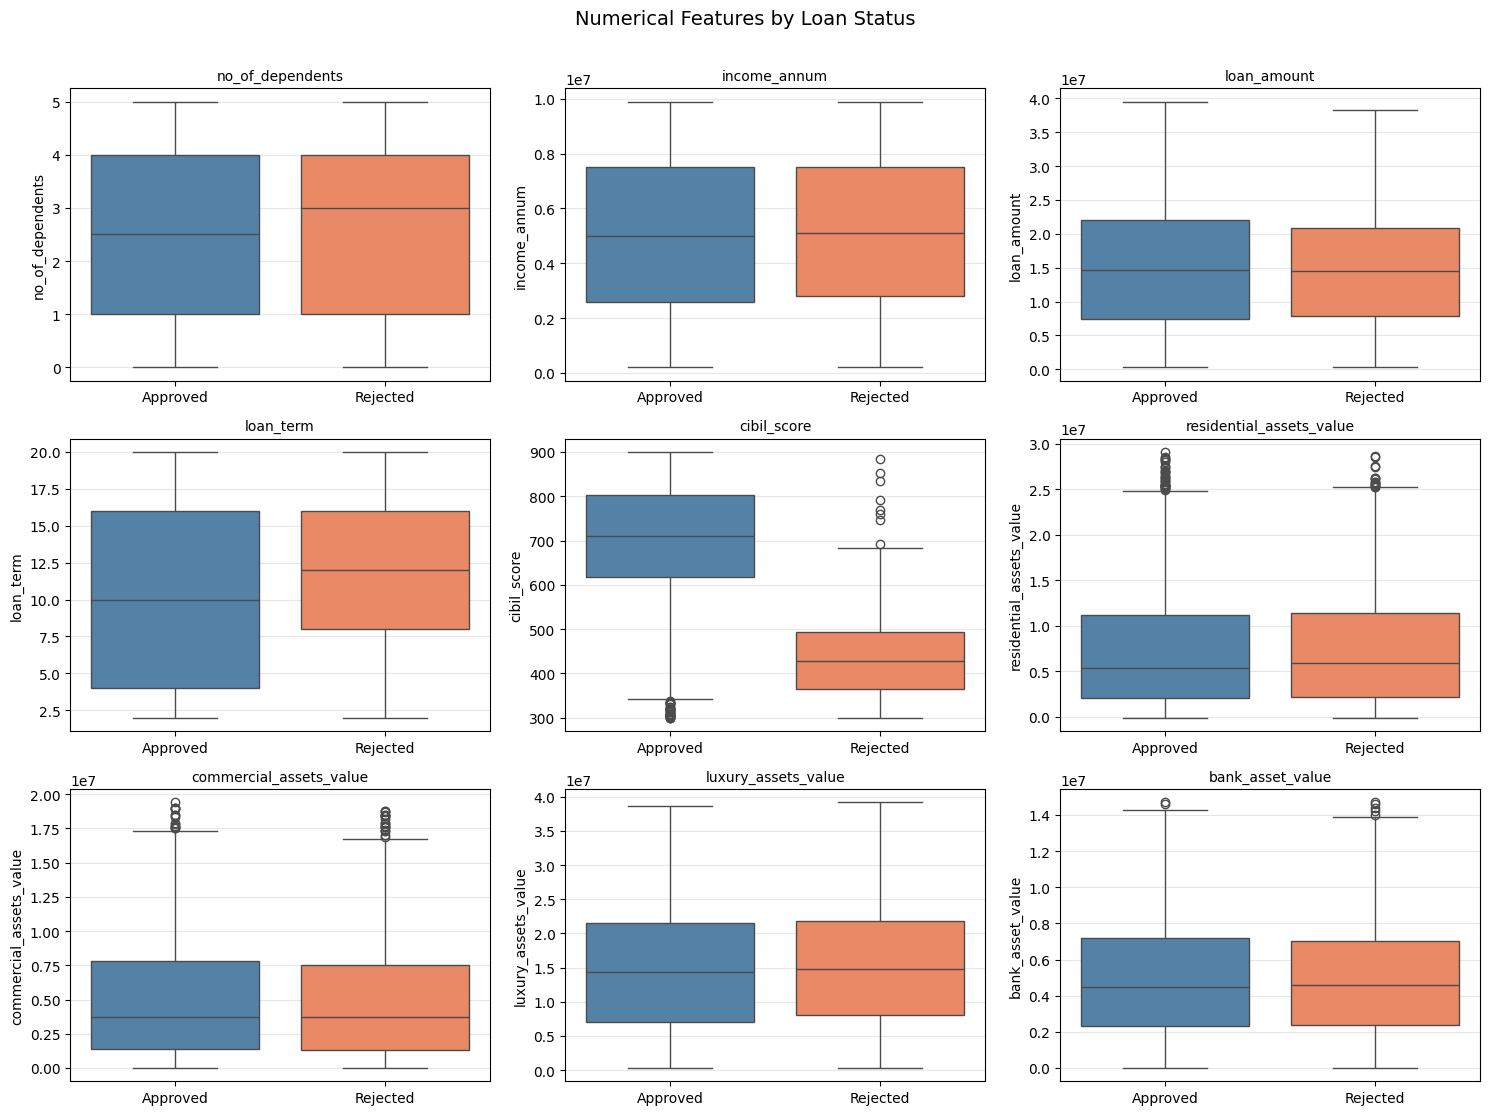

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()

for i, col in enumerate(NUMERICAL_COLS):
    sns.boxplot(
        x=TARGET_COL, y=col, data=df, ax=axes[i],
        palette={'Approved': 'steelblue', 'Rejected': 'coral'}
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Numerical Features by Loan Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Categorical Feature Distributions

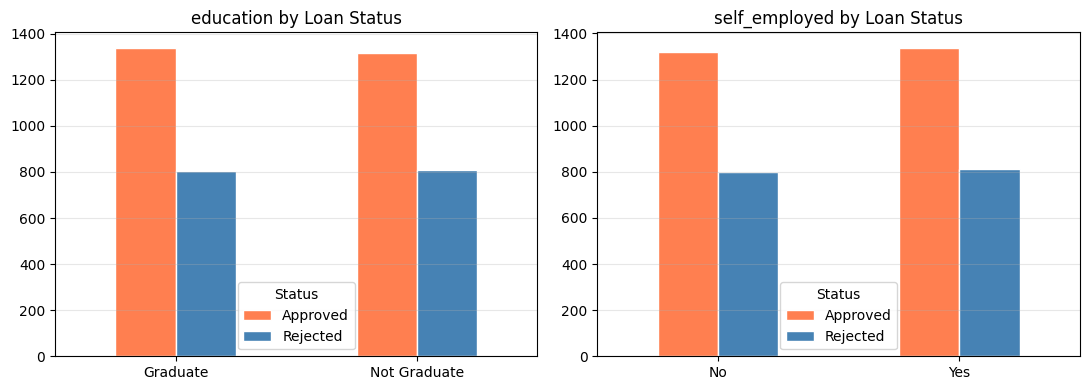

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for i, col in enumerate(CATEGORICAL_COLS):
    df.groupby([col, TARGET_COL]).size().unstack(fill_value=0).plot(
        kind='bar', ax=axes[i],
        color=['coral', 'steelblue'], edgecolor='white'
    )
    axes[i].set_title(f'{col} by Loan Status')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Status')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Correlation Heatmap

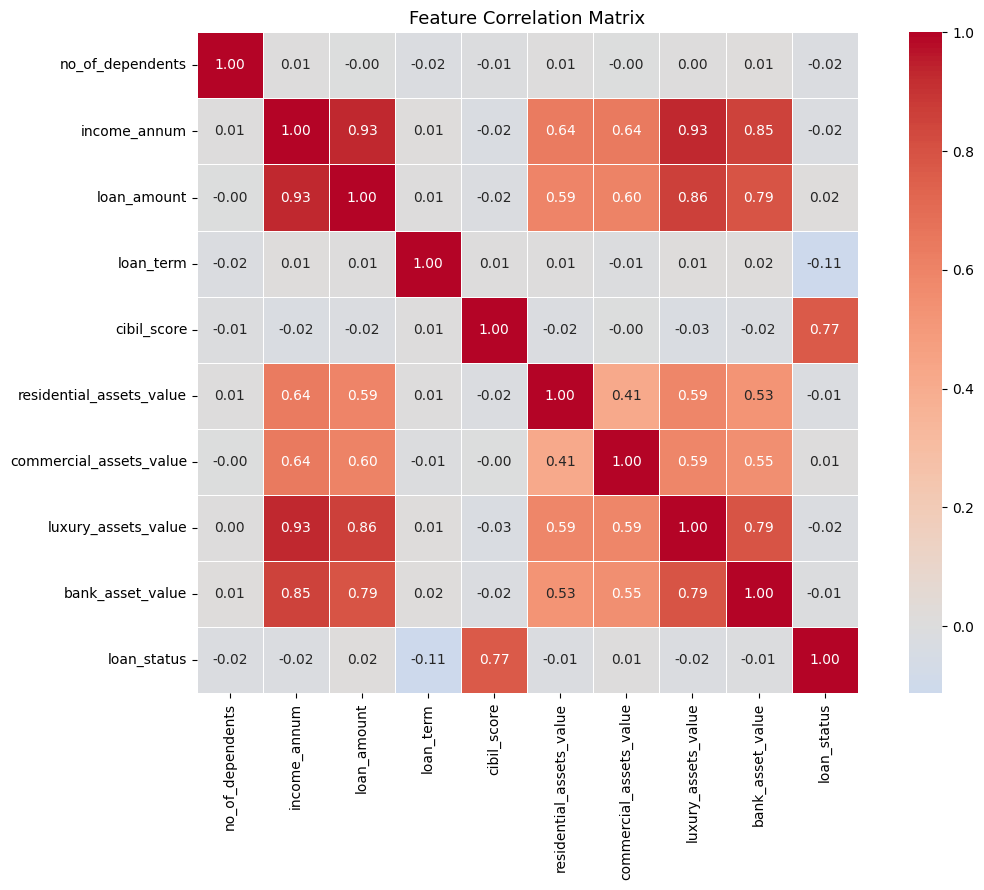

In [8]:
from src.preprocessing import encode_target

df_encoded = encode_target(df.copy())

# Label-encode categorical columns for correlation purposes
from sklearn.preprocessing import LabelEncoder
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

corr = df_encoded[NUMERICAL_COLS + [TARGET_COL]].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, square=True
)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Key Observations

- **Class balance**: 2 656 Approved (62.2 %) vs 1 613 Rejected (37.8 %) — mild imbalance (ratio ≈ 1.65), SMOTE will be applied in notebook 03
- **cibil_score is by far the strongest predictor**: correlation with `loan_status` = **0.77** — all other numerical features have near-zero correlation (< 0.02 in absolute value)
- **cibil_score boxplot (Section 5)**: Approved loans cluster tightly around median ≈ 720 (range 600–900), Rejected loans cluster around median ≈ 450 (range 300–600) — the two boxes barely overlap, making cibil_score a near-perfect separator on its own
- **loan_term boxplot (Section 5)**: Rejected loans have a higher median term (≈ 14 years) vs Approved (≈ 10 years) — longer loan terms carry higher repayment risk, confirming the −0.11 correlation
- **Asset and income features** show flat, overlapping boxplots between Approved and Rejected — they contribute very little predictive signal despite their right-skewed distributions
- **Categorical features** (education, self_employed) show virtually identical approval rates across their categories — Graduate vs Not Graduate and Yes vs No split almost 50/50 within each class
- **No missing values** in this dataset (0 missing cells) — the imputation step in notebook 02 is included as defensive programming for robustness